In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df = pd.read_csv("system_logs_dataset_v2.csv")

In [4]:
df.head()

,id,timestamp,service,system_state,cpu_percent,memory_percent,disk_percent,response_time_ms,status_code,log_level,message,is_anomaly
0,1,2026-01-01 00:00:01,user-service,Healthy,46.5,60.2,31.9,135.1,200,INFO,Health check passed,0
1,2,2026-01-01 00:00:03,mysql-db,Healthy,33.0,29.8,44.4,194.6,201,INFO,Query executed,0
2,3,2026-01-01 00:00:05,user-service,Healthy,83.0,50.9,41.7,135.8,200,INFO,Health check passed,0
3,4,2026-01-01 00:00:06,order-service,Healthy,71.6,44.8,25.2,346.4,200,INFO,Health check passed,0
4,5,2026-01-01 00:00:07,payment-service,Healthy,45.5,58.2,25.9,109.1,404,INFO,Health check passed,0


In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["second"] = df["timestamp"].dt.second

In [6]:
print(df.shape)

(50000, 18)


In [7]:
df.drop(columns =['timestamp','id'],inplace = True)

In [8]:
print(df.columns)

Index(['service', 'system_state', 'cpu_percent', 'memory_percent',
       'disk_percent', 'response_time_ms', 'status_code', 'log_level',
       'message', 'is_anomaly', 'year', 'month', 'day', 'hour', 'minute',
       'second'],
      dtype='str')


# visualization

<Axes: xlabel='service', ylabel='status_code'>

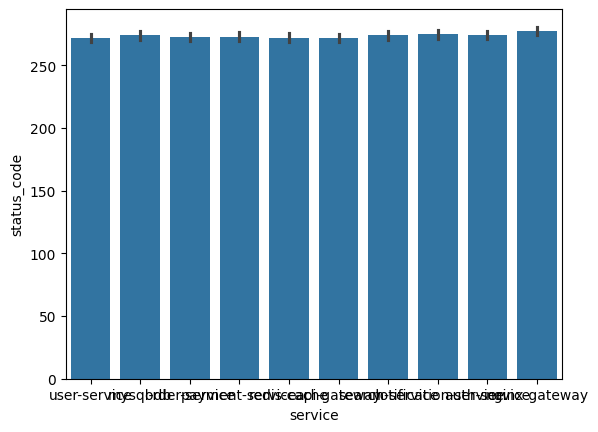

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(x="service",y="status_code",data=df)

In [10]:
plt.show()

<Axes: xlabel='cpu_percent', ylabel='memory_percent'>

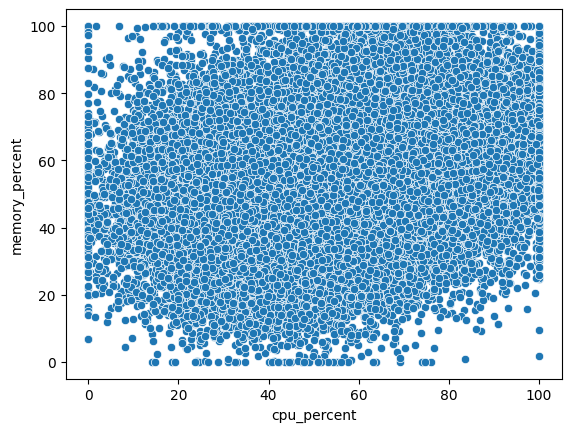

In [11]:
sns.scatterplot(x="cpu_percent",y="memory_percent",data=df)



In [12]:
df[['cpu_percent','memory_percent']].corr()



,cpu_percent,memory_percent
cpu_percent,1.000000,0.275117
memory_percent,0.275117,1.000000


<Axes: xlabel='memory_percent', ylabel='is_anomaly'>

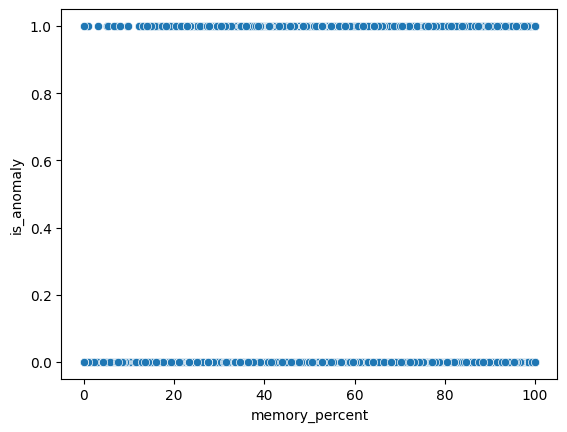

In [13]:
sns.scatterplot(x="memory_percent",y="is_anomaly",data=df)



<Axes: xlabel='cpu_percent', ylabel='status_code'>

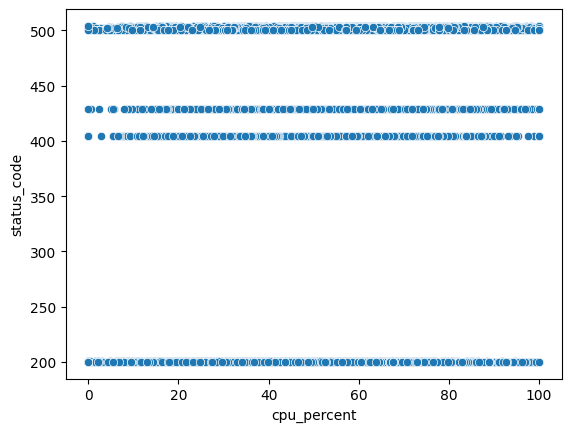

In [14]:
sns.scatterplot(x="cpu_percent",y="status_code",data=df)



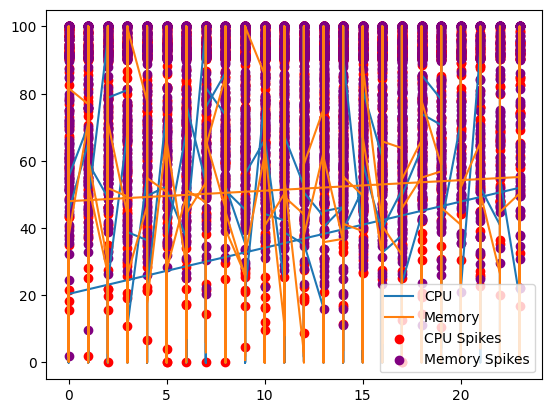

In [15]:
spikes = df[(df['cpu_percent'] > 90) | (df['memory_percent'] > 90)]
plt.plot(df['hour'], df['cpu_percent'], label='CPU')
plt.plot(df['hour'], df['memory_percent'], label='Memory')
plt.scatter(spikes['hour'], spikes['cpu_percent'], color='red', label='CPU Spikes')
plt.scatter(spikes['hour'], spikes['memory_percent'], color='purple', label='Memory Spikes')
plt.legend()
plt.show()




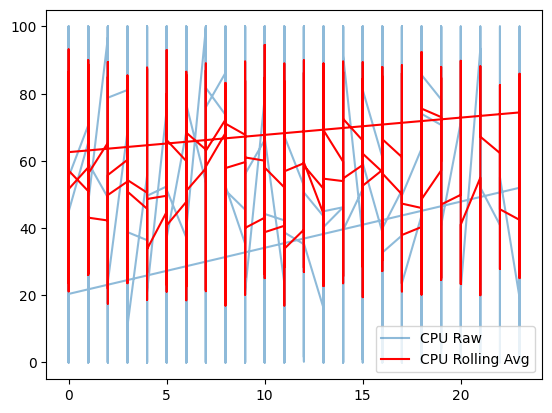

In [16]:
df['cpu_roll'] = df['cpu_percent'].rolling(window=5).mean()
plt.plot(df['hour'], df['cpu_percent'], alpha=0.5, label='CPU Raw')
plt.plot(df['hour'], df['cpu_roll'], color='red', label='CPU Rolling Avg')
plt.legend()
plt.show()



<Axes: xlabel='hour', ylabel='cpu_percent'>

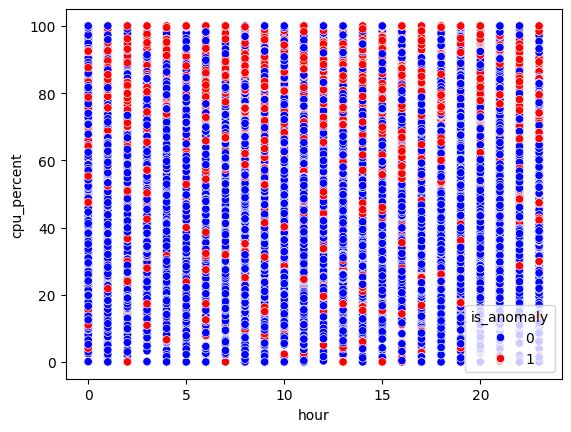

In [17]:
sns.scatterplot(x="hour", y="cpu_percent", hue="is_anomaly", data=df, palette={0:"blue",1:"red"})



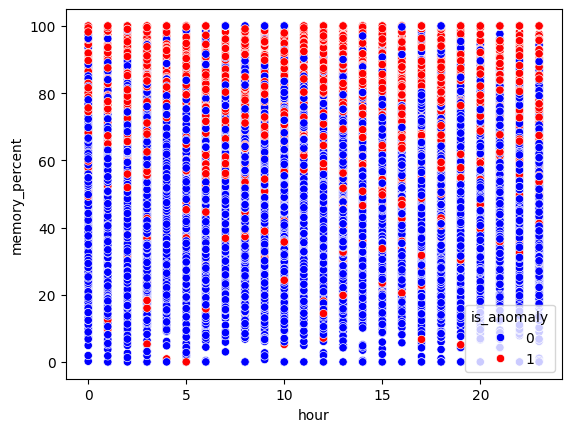

In [18]:
sns.scatterplot(x="hour", y="memory_percent", hue="is_anomaly", data=df, palette={0:"blue",1:"red"})
plt.show()

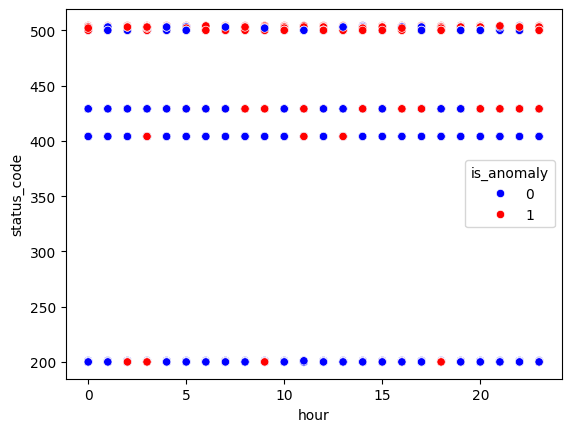

In [19]:
sns.scatterplot(x="hour", y="status_code", hue="is_anomaly", data=df, palette={0:"blue",1:"red"})
plt.show()

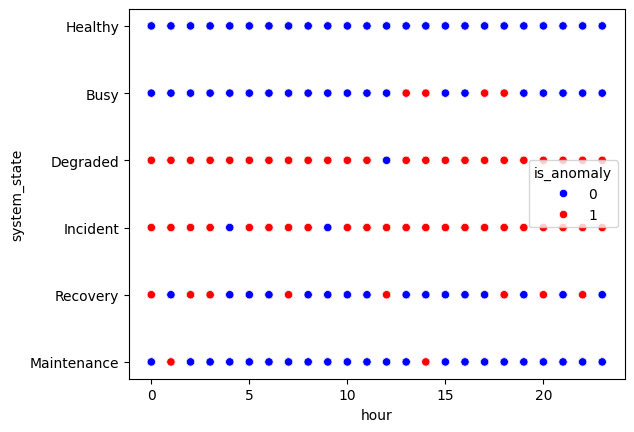

In [20]:
sns.scatterplot(x="hour", y="system_state", hue="is_anomaly", data=df, palette={0:"blue",1:"red"})
plt.show()

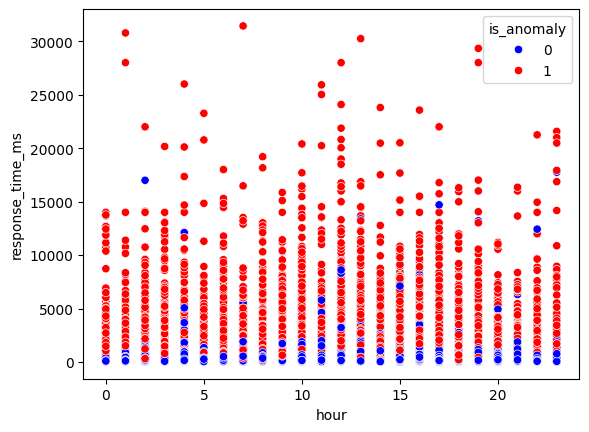

In [21]:
sns.scatterplot(x="hour", y="response_time_ms", hue="is_anomaly", data=df, palette={0:"blue",1:"red"})
plt.show()

In [22]:
print(df.columns)

Index(['service', 'system_state', 'cpu_percent', 'memory_percent',
       'disk_percent', 'response_time_ms', 'status_code', 'log_level',
       'message', 'is_anomaly', 'year', 'month', 'day', 'hour', 'minute',
       'second', 'cpu_roll'],
      dtype='str')


In [23]:
df.head(3)

,service,system_state,cpu_percent,memory_percent,disk_percent,response_time_ms,status_code,log_level,message,is_anomaly,year,month,day,hour,minute,second,cpu_roll
0,user-service,Healthy,46.5,60.2,31.9,135.1,200,INFO,Health check passed,0,2026,1,1,0,0,1,NaN
1,mysql-db,Healthy,33.0,29.8,44.4,194.6,201,INFO,Query executed,0,2026,1,1,0,0,3,NaN
2,user-service,Healthy,83.0,50.9,41.7,135.8,200,INFO,Health check passed,0,2026,1,1,0,0,5,NaN


In [24]:
# system state biasness launa sakxa so drop gareko healthy column le 
df.drop(columns= 'system_state',inplace = True)

In [25]:
df.drop(columns= 'cpu_roll',inplace = True)

In [26]:
df.head(3)

,service,cpu_percent,memory_percent,disk_percent,response_time_ms,status_code,log_level,message,is_anomaly,year,month,day,hour,minute,second
0,user-service,46.5,60.2,31.9,135.1,200,INFO,Health check passed,0,2026,1,1,0,0,1
1,mysql-db,33.0,29.8,44.4,194.6,201,INFO,Query executed,0,2026,1,1,0,0,3
2,user-service,83.0,50.9,41.7,135.8,200,INFO,Health check passed,0,2026,1,1,0,0,5


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   service           50000 non-null  str    
 1   cpu_percent       50000 non-null  float64
 2   memory_percent    50000 non-null  float64
 3   disk_percent      50000 non-null  float64
 4   response_time_ms  50000 non-null  float64
 5   status_code       50000 non-null  int64  
 6   log_level         50000 non-null  str    
 7   message           50000 non-null  str    
 8   is_anomaly        50000 non-null  int64  
 9   year              50000 non-null  int32  
 10  month             50000 non-null  int32  
 11  day               50000 non-null  int32  
 12  hour              50000 non-null  int32  
 13  minute            50000 non-null  int32  
 14  second            50000 non-null  int32  
dtypes: float64(4), int32(6), int64(2), str(3)
memory usage: 4.6 MB


In [28]:
print(df['service'].unique())

<StringArray>
[        'user-service',             'mysql-db',        'order-service',
      'payment-service',          'redis-cache',          'api-gateway',
       'search-service', 'notification-service',         'auth-service',
        'nginx-gateway']
Length: 10, dtype: str


# Encoding

In [29]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
service_encoded = encoder.fit_transform(df[['service']])
encoded_df = pd.DataFrame(service_encoded, columns=encoder.get_feature_names_out(['service']))
df_encoded = pd.concat([df, encoded_df], axis=1)
df_encoded

,service,cpu_percent,memory_percent,disk_percent,response_time_ms,status_code,log_level,message,is_anomaly,year,...,service_api-gateway,service_auth-service,service_mysql-db,service_nginx-gateway,service_notification-service,service_order-service,service_payment-service,service_redis-cache,service_search-service,service_user-service
0,user-service,46.5,60.2,31.9,135.1,200,INFO,Health check passed,0,2026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,mysql-db,33.0,29.8,44.4,194.6,201,INFO,Query executed,0,2026,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,user-service,83.0,50.9,41.7,135.8,200,INFO,Health check passed,0,2026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,order-service,71.6,44.8,25.2,346.4,200,INFO,Health check passed,0,2026,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,payment-service,45.5,58.2,25.9,109.1,404,INFO,Health check passed,0,2026,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,user-service,39.9,80.5,29.2,1163.7,200,INFO,Slow response observed,0,2026,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
49996,nginx-gateway,60.3,52.7,35.4,293.7,429,INFO,High inbound traffic,0,2026,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
49997,payment-service,30.8,41.5,51.7,910.5,500,WARNING,Slow response observed,0,2026,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
49998,auth-service,96.3,61.8,58.4,430.6,200,INFO,Token validation queue backing up,1,2026,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
 df_encoded.drop(columns=['service'],inplace = True)   # feature matrix


In [31]:
print(df_encoded["log_level"].unique())

<StringArray>
['INFO', 'WARNING', 'ERROR']
Length: 3, dtype: str


In [32]:
mapping = {"INFO":0,'WARNING':1,'ERROR':2}
df_encoded['log_level'] = df_encoded['log_level'].map(mapping)
df_encoded['log_level'] = df_encoded['log_level'].astype(int)

In [33]:
df_encoded.head(3)

,cpu_percent,memory_percent,disk_percent,response_time_ms,status_code,log_level,message,is_anomaly,year,month,...,service_api-gateway,service_auth-service,service_mysql-db,service_nginx-gateway,service_notification-service,service_order-service,service_payment-service,service_redis-cache,service_search-service,service_user-service
0,46.5,60.2,31.9,135.1,200,0,Health check passed,0,2026,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,33.0,29.8,44.4,194.6,201,0,Query executed,0,2026,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,83.0,50.9,41.7,135.8,200,0,Health check passed,0,2026,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [34]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   cpu_percent                   50000 non-null  float64
 1   memory_percent                50000 non-null  float64
 2   disk_percent                  50000 non-null  float64
 3   response_time_ms              50000 non-null  float64
 4   status_code                   50000 non-null  int64  
 5   log_level                     50000 non-null  int64  
 6   message                       50000 non-null  str    
 7   is_anomaly                    50000 non-null  int64  
 8   year                          50000 non-null  int32  
 9   month                         50000 non-null  int32  
 10  day                           50000 non-null  int32  
 11  hour                          50000 non-null  int32  
 12  minute                        50000 non-null  int32  
 13  second      

# messages encoding

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)  # limit features for efficiency

# Fit and transform the message column
tfidf_matrix = vectorizer.fit_transform(df_encoded['message'])

# Convert to DataFrame for readability
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

tfidf_df.head(3)
print(tfidf_df.shape)

(50000, 124)


In [36]:
final_df = pd.concat([df_encoded,tfidf_df],axis = 1)


In [37]:
final_df.drop(columns = ['message'],inplace = True)

In [38]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 147 entries, cpu_percent to write
dtypes: float64(138), int32(6), int64(3)
memory usage: 54.9 MB


# Models Training

Here i am going to make it first with unsupervised learning using isolation forest and then random forest classifier taking aomaly ads column

# Isolation Forest

In [39]:
from sklearn.model_selection import train_test_split
train_df = final_df.drop(columns = ['is_anomaly'])


In [40]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.24204, random_state=42)
iso.fit(train_df)   # X = all numeric features, no anomaly column
y_pred = iso.predict(train_df)   # -1 anomaly, 1 normal

In [41]:
print(y_pred)

[ 1  1  1 ... -1 -1 -1]


In [42]:
df['predicted_anomaly'] = [1 if val == -1 else 0 for val in y_pred]

In [43]:
df.head()

,service,cpu_percent,memory_percent,disk_percent,response_time_ms,status_code,log_level,message,is_anomaly,year,month,day,hour,minute,second,predicted_anomaly
0,user-service,46.5,60.2,31.9,135.1,200,INFO,Health check passed,0,2026,1,1,0,0,1,0
1,mysql-db,33.0,29.8,44.4,194.6,201,INFO,Query executed,0,2026,1,1,0,0,3,0
2,user-service,83.0,50.9,41.7,135.8,200,INFO,Health check passed,0,2026,1,1,0,0,5,0
3,order-service,71.6,44.8,25.2,346.4,200,INFO,Health check passed,0,2026,1,1,0,0,6,0
4,payment-service,45.5,58.2,25.9,109.1,404,INFO,Health check passed,0,2026,1,1,0,0,7,0


In [44]:
from sklearn.metrics import classification_report

print(classification_report(df['is_anomaly'], df['predicted_anomaly']))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     37898
           1       0.41      0.41      0.41     12102

    accuracy                           0.72     50000
   macro avg       0.61      0.61      0.61     50000
weighted avg       0.72      0.72      0.72     50000



In [45]:
df['is_anomaly'].sum() / len(df)

np.float64(0.24204)

# LOF

In [46]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=5, contamination=0.2)
lof.fit(train_df)
y_pred = lof.fit_predict(train_df)

In [47]:
print(y_pred)

[ 1  1 -1 ...  1  1  1]


In [48]:
from sklearn.metrics import classification_report
df['predicted_anomaly'] = [1 if val == -1 else 0 for val in y_pred]
print(classification_report(df['is_anomaly'], df['predicted_anomaly']))

              precision    recall  f1-score   support

           0       0.77      0.81      0.79     37898
           1       0.27      0.22      0.25     12102

    accuracy                           0.67     50000
   macro avg       0.52      0.52      0.52     50000
weighted avg       0.65      0.67      0.66     50000



# SVM(Support Vector Machine)

In [ ]:
from sklearn.svm import OneClassSVM

# Train One-Class SVM
ocsvm = OneClassSVM(kernel='rbf', nu=0.20, gamma='scale')
ocsvm.fit(train_df)


In [ ]:
y_pred = ocsvm.predict(train_df)
print(y_pred)

In [ ]:
from sklearn.metrics import classification_report
df['predicted_anomaly'] = [1 if val == -1 else 0 for val in y_pred]
print(classification_report(df['is_anomaly'], df['predicted_anomaly']))

# Random FOrest Claassifier

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

x_train,x_test,y_train,y_test = train_test_split(final_df.drop(columns = 'is_anomaly'),final_df['is_anomaly'],stratify = final_df['is_anomaly'],test_size = 0.2,random_state = 42)


In [ ]:
rf = RandomForestClassifier(n_estimators=250,
    random_state=42,
    oob_score=True,
    class_weight="balanced")

rf.fit(x_train,y_train)

In [ ]:
y_pred = rf.predict(x_test)
print(classification_report(y_test, y_pred))


# Auto Encoder

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(train_df, test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

input_dim = X_train_scaled.shape[1]

autoencoder = Sequential([
    Dense(32, activation='relu', input_shape=(input_dim,)),
    Dense(16, activation='relu'),   # bottleneck
    Dense(32, activation='relu'),
    Dense(input_dim, activation='sigmoid')  # reconstruct
])

autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    shuffle=True
)

In [ ]:
reconstructions = autoencoder.predict(X_test_scaled)
errors = np.mean(np.square(X_test_scaled - reconstructions), axis=1)


In [ ]:
threshold = np.percentile(errors, 95)  # top 5% as anomalies
y_pred = (errors > threshold).astype(int)

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
import joblib

# Save model
joblib.dump(rf, "anomalymodel.pkl")
